In [3]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

In [4]:
file_path = "spy_options_data_24.json"   

with open(file_path, "r") as f:
    raw = json.load(f)

# raw is a list of lists
records = [item for sublist in raw for item in sublist]

df = pd.DataFrame(records)

print("Raw shape:", df.shape)
print(df.head())
print(df.columns.tolist())

Raw shape: (2292798, 20)
           contractID symbol  expiration  strike  type   last   mark    bid  \
0  SPY240102C00402000    SPY  2024-01-02  402.00  call  69.97  70.77  70.68   
1  SPY240102P00402000    SPY  2024-01-02  402.00   put   0.02   0.01   0.00   
2  SPY240102C00403000    SPY  2024-01-02  403.00  call  68.97  69.78  69.68   
3  SPY240102P00403000    SPY  2024-01-02  403.00   put   0.01   0.01   0.00   
4  SPY240102C00404000    SPY  2024-01-02  404.00  call  68.64  68.77  68.68   

  bid_size    ask ask_size volume open_interest        date  \
0      100  70.85      100    130             1  2024-01-02   
1        0   0.01     4204      0           303  2024-01-02   
2      100  69.89      100      9             0  2024-01-02   
3        0   0.01     3671      1             8  2024-01-02   
4      100  68.85      100      1             1  2024-01-02   

  implied_volatility     delta    gamma     theta     vega       rho  
0            1.24983   0.99396  0.00055  -0.32269 

In [8]:
numeric_cols = [
    "strike", "last", "mark", "bid", "bid_size", "ask", "ask_size",
    "volume", "open_interest", "implied_volatility", "delta",
    "gamma", "theta", "vega", "rho"
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["expiration"] = pd.to_datetime(df["expiration"], errors="coerce")
df["type"] = df["type"].str.lower().str.strip()

df["mid_price"] = (df["bid"] + df["ask"]) / 2
df["spread"] = df["ask"] - df["bid"]
df["rel_spread"] = df["spread"] / df["mid_price"]

df["T"] = (df["expiration"] - df["date"]).dt.days / 365.0

# basic cleaning
df = df.dropna(subset=[
    "date", "expiration", "type", "strike", "bid", "ask",
    "mid_price", "implied_volatility", "T"
])

df = df[df["type"].isin(["call", "put"])]
df = df[df["T"] > 0]
df = df[df["mid_price"] > 0]
df = df[df["bid"] >= 0]
df = df[df["ask"] > 0]
df = df[df["spread"] >= 0]

print("After basic cleaning:", df.shape)

After basic cleaning: (2225428, 24)


# adding the spot price

In [9]:
spy = pd.read_csv("SPY_prices.csv")   
print(spy.head())
print(spy.columns.tolist())

      Open      High       Low    Close   Volume        Date
0  24.4689  24.46890  24.34720  24.4516  1003200  1993-01-28
1  24.4689  24.62550  24.46890  24.6255   480500  1993-01-31
2  24.6081  24.69500  24.55590  24.6776   201300  1993-02-01
3  24.7124  24.95590  24.69500  24.9385   529400  1993-02-02
4  25.0254  25.03415  25.03415  25.0429   531500  1993-02-03
['Open', 'High', 'Low', 'Close', 'Volume', 'Date']


In [10]:
spy["date"] = pd.to_datetime(spy["Date"], errors="coerce")
spy["S"] = pd.to_numeric(spy["Close"], errors="coerce")

spy = spy[["date", "S"]].dropna().sort_values("date")
df = df.sort_values("date")

# backward asof merge for non-trading days / timestamp mismatch
df = pd.merge_asof(df, spy, on="date", direction="backward")

print("Missing spot values:", df["S"].isna().sum())
df = df.dropna(subset=["S"])

print("After spot merge:", df.shape)
print(df[["date", "S"]].head())

Missing spot values: 0
After spot merge: (2225428, 25)
        date         S
0 2024-01-02  461.4658
1 2024-01-02  461.4658
2 2024-01-02  461.4658
3 2024-01-02  461.4658
4 2024-01-02  461.4658


In [11]:
print(f"  Spot price range: ${df['S'].min():.2f} - ${df['S'].max():.2f}")

  Spot price range: $459.98 - $603.96


In [12]:
df["moneyness"] = df["strike"] / df["S"]
df["log_moneyness"] = np.log(df["strike"] / df["S"])

print(df[[
    "S", "strike", "mid_price", "implied_volatility",
    "delta", "gamma", "theta", "vega", "rho", "T", "moneyness"
]].describe())

                  S        strike     mid_price  implied_volatility  \
count  2.225428e+06  2.225428e+06  2.225428e+06        2.225428e+06   
mean   5.385547e+02  4.969751e+02  5.276584e+01        2.595628e-01   
std    3.759543e+01  1.208905e+02  7.756460e+01        2.770495e-01   
min    4.599794e+02  1.200000e+02  5.000000e-03        9.500000e-04   
25%    5.079087e+02  4.330000e+02  1.440000e+00        1.298900e-01   
50%    5.393334e+02  5.000000e+02  1.499000e+01        1.881200e-01   
75%    5.686705e+02  5.650000e+02  7.357000e+01        3.003100e-01   
max    6.039553e+02  9.100000e+02  4.880500e+02        8.884100e+00   

              delta         gamma         theta          vega           rho  \
count  2.225428e+06  2.225428e+06  2.225428e+06  2.225428e+06  2.225428e+06   
mean   2.029173e-01  5.079980e-03 -7.642748e-02  5.830683e-01  1.250551e-01   
std    5.935667e-01  9.088259e-03  1.313946e-01  7.312844e-01  2.157652e+00   
min   -1.000000e+00  0.000000e+00 -7.583950e

In [13]:
df.shape

(2225428, 27)

In [14]:
# optional filters for more stable EDA
df = df[(df["implied_volatility"] > 0.01) & (df["implied_volatility"] < 1.0)]
df = df[df["rel_spread"] < 0.50]

In [15]:
df.shape

(2034438, 27)

In [16]:
# Spot prices already merged. Prepare data for EDA
print("Preparing data for EDA analysis...")

# Verify moneyness is computed correctly
eda_df = df.copy()

# Basic quality filters
eda_df = eda_df[
    (eda_df["type"].isin(["call", "put"])) &
    (eda_df["T"] > 0) &
    (eda_df["mid_price"] > 0) &
    (eda_df["bid"] >= 0) &
    (eda_df["ask"] > 0) &
    (eda_df["spread"] >= 0)
].copy()

print(f"After quality check: {len(eda_df):,} rows")
print(f"Date range: {eda_df['date'].min().date()} to {eda_df['date'].max().date()}")

Preparing data for EDA analysis...
After quality check: 2,034,438 rows
Date range: 2024-01-02 to 2024-12-31


In [19]:
# Keep all data for comprehensive analysis - no moneyness filter!
# Filters for liquidity only
eda_df = eda_df[
    (eda_df["volume"] >= 1) &
    (eda_df["open_interest"] >= 1) &
    (eda_df["mid_price"] >= 0.01)  # Even allow cheap options
].copy()


bins = [0, 0.85, 0.95, 1.0, 1.05, 1.15, np.inf]

# start as object, not category
eda_df["moneyness_regime"] = None

# puts
put_mask = eda_df["type"].eq("put")
eda_df.loc[put_mask, "moneyness_regime"] = pd.cut(
    eda_df.loc[put_mask, "moneyness"],
    bins=bins,
    labels=["Deep OTM", "OTM", "Near ATM", "Near ITM", "ITM", "Deep ITM"],
).astype(str)

# calls
call_mask = eda_df["type"].eq("call")
eda_df.loc[call_mask, "moneyness_regime"] = pd.cut(
    eda_df.loc[call_mask, "moneyness"],
    bins=bins,
    labels=["Deep ITM", "ITM", "Near ITM", "Near ATM", "OTM", "Deep OTM"],
).astype(str)

# clean any out-of-range values produced as "nan"
eda_df["moneyness_regime"] = eda_df["moneyness_regime"].replace("nan", np.nan)

# optional: convert to ordered category for plotting/reporting
ordered_levels = ["Deep OTM", "OTM", "Near ATM", "Near ITM", "ITM", "Deep ITM"]
eda_df["moneyness_regime"] = pd.Categorical(
    eda_df["moneyness_regime"],
    categories=ordered_levels,
    ordered=True
)

print("EDA full data shape (no moneyness filter):", eda_df.shape)
print("\nMoneyness distribution:")
print(eda_df["moneyness_regime"].value_counts(dropna=False).sort_index())

EDA full data shape (no moneyness filter): (940148, 28)

Moneyness distribution:
moneyness_regime
Deep OTM    189567
OTM         203059
Near ATM    239443
Near ITM    191700
ITM          82577
Deep ITM     33802
Name: count, dtype: int64


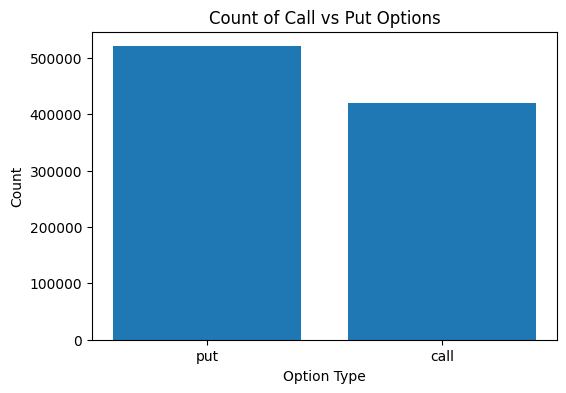

In [20]:
type_counts = eda_df["type"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(type_counts.index, type_counts.values)
plt.title("Count of Call vs Put Options")
plt.xlabel("Option Type")
plt.ylabel("Count")
plt.show()

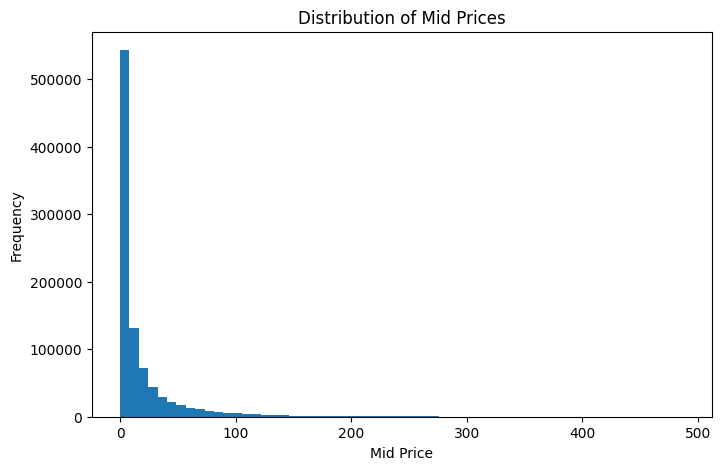

In [21]:
plt.figure(figsize=(8, 5))
plt.hist(eda_df["mid_price"], bins=60)
plt.title("Distribution of Mid Prices")
plt.xlabel("Mid Price")
plt.ylabel("Frequency")
plt.show()

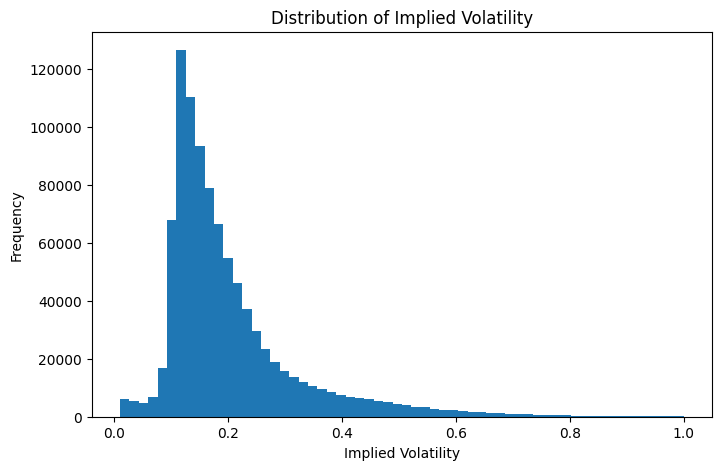

In [22]:
plt.figure(figsize=(8, 5))
plt.hist(eda_df["implied_volatility"], bins=60)
plt.title("Distribution of Implied Volatility")
plt.xlabel("Implied Volatility")
plt.ylabel("Frequency")
plt.show()

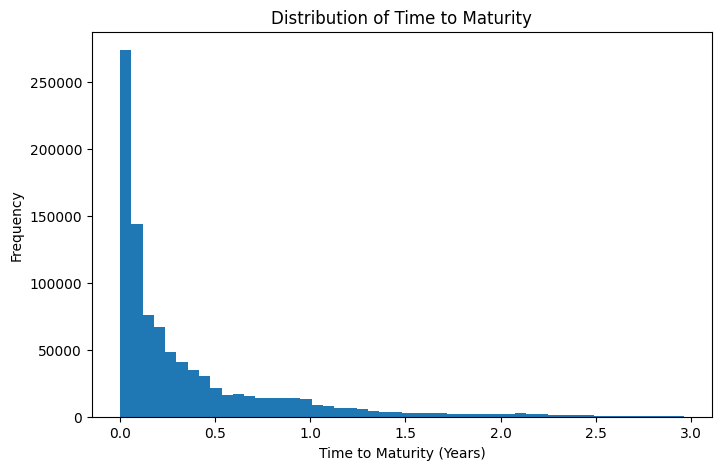

In [23]:
plt.figure(figsize=(8, 5))
plt.hist(eda_df["T"], bins=50)
plt.title("Distribution of Time to Maturity")
plt.xlabel("Time to Maturity (Years)")
plt.ylabel("Frequency")
plt.show()

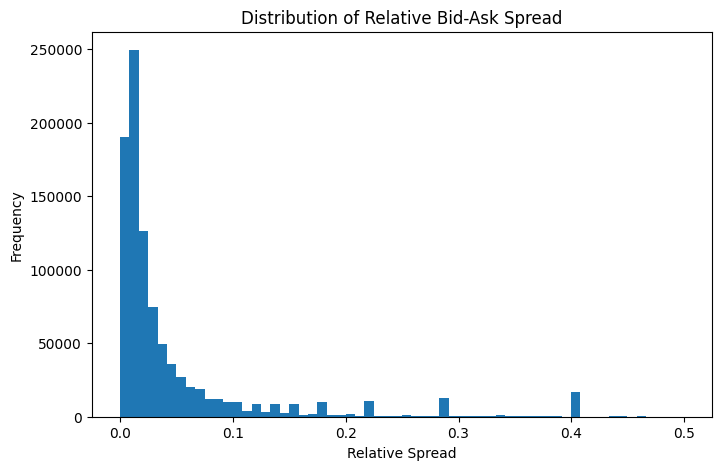

In [24]:
plt.figure(figsize=(8, 5))
plt.hist(eda_df["rel_spread"], bins=60)
plt.title("Distribution of Relative Bid-Ask Spread")
plt.xlabel("Relative Spread")
plt.ylabel("Frequency")
plt.show()

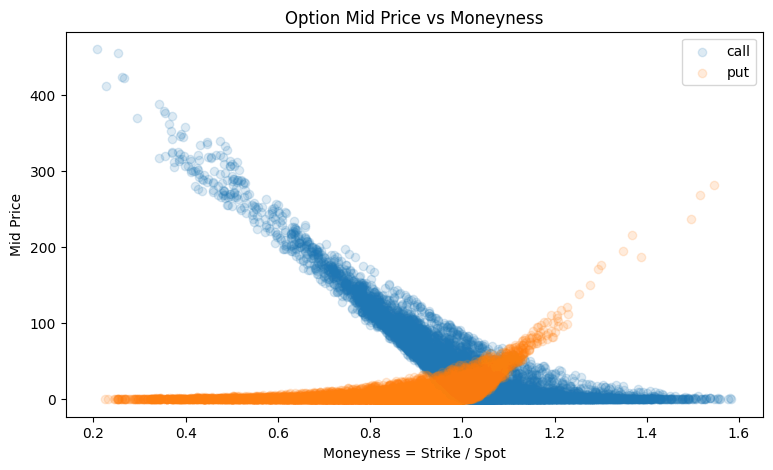

In [25]:
sample_df = eda_df.sample(min(30000, len(eda_df)), random_state=42)

plt.figure(figsize=(9, 5))
for opt_type in ["call", "put"]:
    temp = sample_df[sample_df["type"] == opt_type]
    plt.scatter(temp["moneyness"], temp["mid_price"], alpha=0.15, label=opt_type)

plt.title("Option Mid Price vs Moneyness")
plt.xlabel("Moneyness = Strike / Spot")
plt.ylabel("Mid Price")
plt.legend()
plt.show()

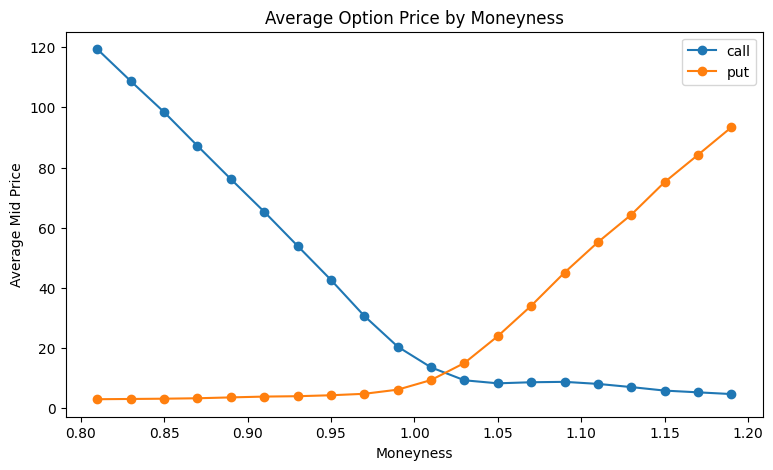

In [26]:
eda_df["moneyness_bin"] = pd.cut(eda_df["moneyness"], bins=np.arange(0.8, 1.201, 0.02))

binned_price = (
    eda_df.groupby(["type", "moneyness_bin"], observed=False)["mid_price"]
    .mean()
    .reset_index()
)

binned_price["moneyness_mid"] = binned_price["moneyness_bin"].apply(lambda x: x.mid if pd.notnull(x) else np.nan)

plt.figure(figsize=(9, 5))
for opt_type in ["call", "put"]:
    temp = binned_price[binned_price["type"] == opt_type]
    plt.plot(temp["moneyness_mid"], temp["mid_price"], marker="o", label=opt_type)

plt.title("Average Option Price by Moneyness")
plt.xlabel("Moneyness")
plt.ylabel("Average Mid Price")
plt.legend()
plt.show()

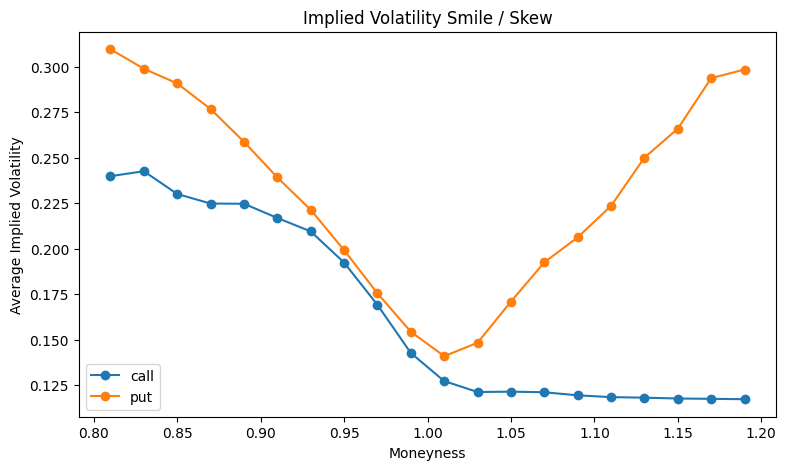

In [27]:
iv_smile = (
    eda_df.groupby(["type", "moneyness_bin"], observed=False)["implied_volatility"]
    .mean()
    .reset_index()
)

iv_smile["moneyness_mid"] = iv_smile["moneyness_bin"].apply(lambda x: x.mid if pd.notnull(x) else np.nan)

plt.figure(figsize=(9, 5))
for opt_type in ["call", "put"]:
    temp = iv_smile[iv_smile["type"] == opt_type]
    plt.plot(temp["moneyness_mid"], temp["implied_volatility"], marker="o", label=opt_type)

plt.title("Implied Volatility Smile / Skew")
plt.xlabel("Moneyness")
plt.ylabel("Average Implied Volatility")
plt.legend()
plt.show()

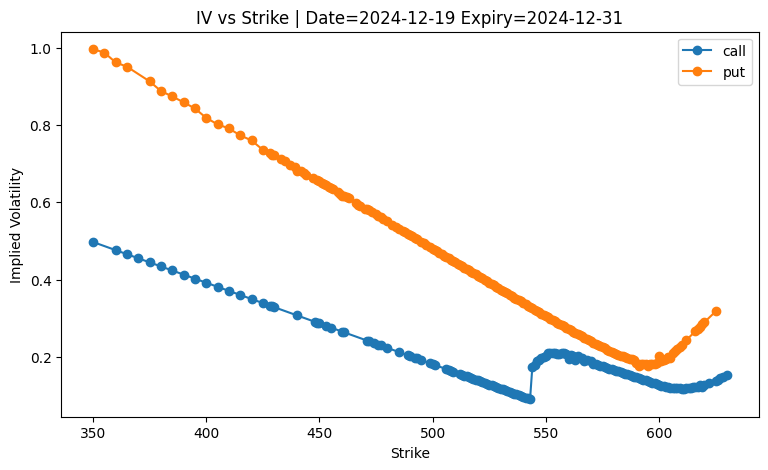

In [28]:
cross_section = (
    eda_df.groupby(["date", "expiration"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .iloc[0]
)

d0 = cross_section["date"]
e0 = cross_section["expiration"]

slice_df = eda_df[(eda_df["date"] == d0) & (eda_df["expiration"] == e0)].copy()

plt.figure(figsize=(9, 5))
for opt_type in ["call", "put"]:
    temp = slice_df[slice_df["type"] == opt_type].sort_values("strike")
    plt.plot(temp["strike"], temp["implied_volatility"], marker="o", linestyle="-", label=opt_type)

plt.title(f"IV vs Strike | Date={d0.date()} Expiry={e0.date()}")
plt.xlabel("Strike")
plt.ylabel("Implied Volatility")
plt.legend()
plt.show()

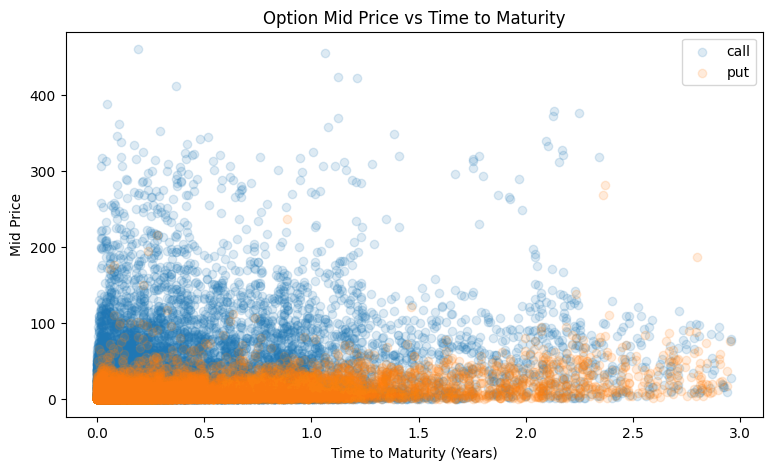

In [29]:
sample_df = eda_df.sample(min(30000, len(eda_df)), random_state=42)

plt.figure(figsize=(9, 5))
for opt_type in ["call", "put"]:
    temp = sample_df[sample_df["type"] == opt_type]
    plt.scatter(temp["T"], temp["mid_price"], alpha=0.15, label=opt_type)

plt.title("Option Mid Price vs Time to Maturity")
plt.xlabel("Time to Maturity (Years)")
plt.ylabel("Mid Price")
plt.legend()
plt.show()

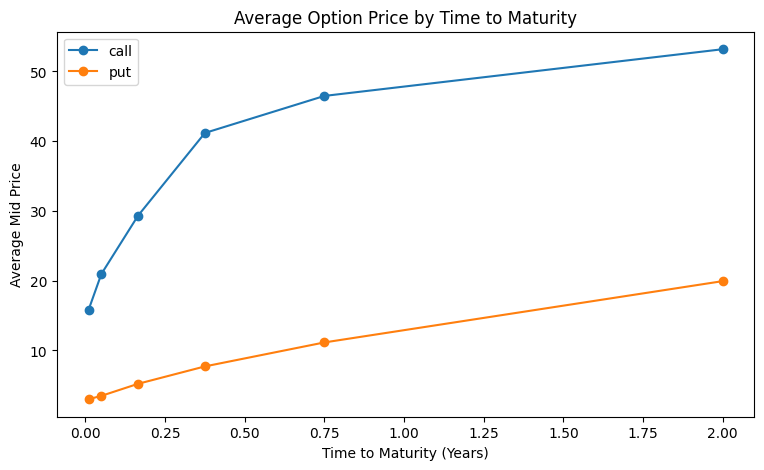

In [30]:
eda_df["T_bin"] = pd.cut(eda_df["T"], bins=[0, 0.02, 0.08, 0.25, 0.5, 1.0, 3.0])

price_by_T = (
    eda_df.groupby(["type", "T_bin"], observed=False)["mid_price"]
    .mean()
    .reset_index()
)

price_by_T["T_mid"] = price_by_T["T_bin"].apply(lambda x: x.mid if pd.notnull(x) else np.nan)

plt.figure(figsize=(9, 5))
for opt_type in ["call", "put"]:
    temp = price_by_T[price_by_T["type"] == opt_type]
    plt.plot(temp["T_mid"], temp["mid_price"], marker="o", label=opt_type)

plt.title("Average Option Price by Time to Maturity")
plt.xlabel("Time to Maturity (Years)")
plt.ylabel("Average Mid Price")
plt.legend()
plt.show()

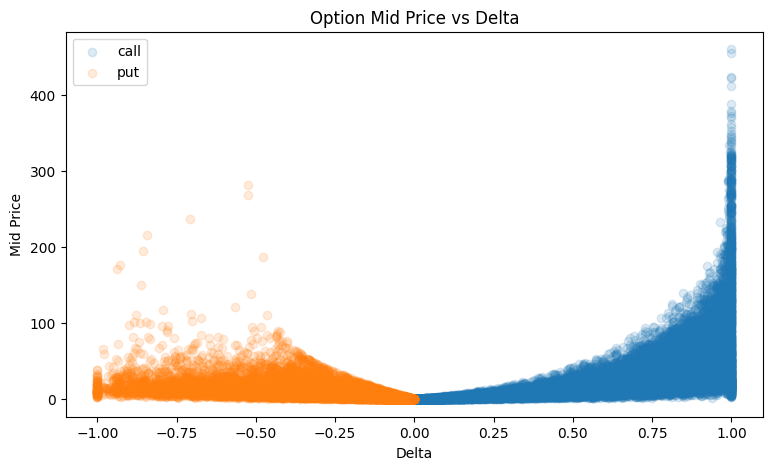

In [31]:
sample_df = eda_df.sample(min(30000, len(eda_df)), random_state=42)

plt.figure(figsize=(9, 5))
for opt_type in ["call", "put"]:
    temp = sample_df[sample_df["type"] == opt_type]
    plt.scatter(temp["delta"], temp["mid_price"], alpha=0.15, label=opt_type)

plt.title("Option Mid Price vs Delta")
plt.xlabel("Delta")
plt.ylabel("Mid Price")
plt.legend()
plt.show()

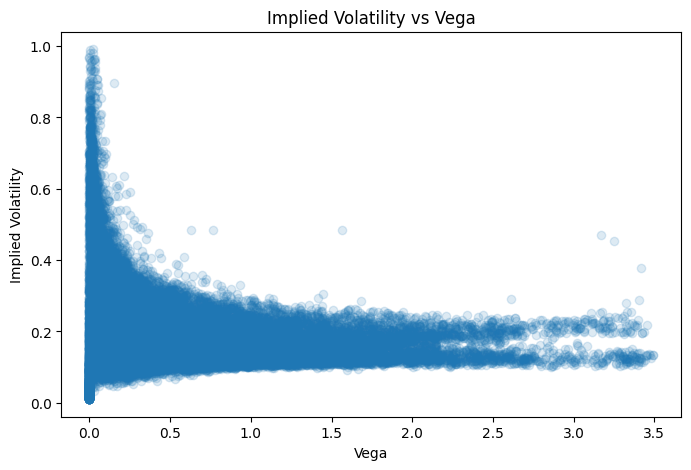

In [32]:
plt.figure(figsize=(8, 5))
plt.scatter(sample_df["vega"], sample_df["implied_volatility"], alpha=0.15)
plt.title("Implied Volatility vs Vega")
plt.xlabel("Vega")
plt.ylabel("Implied Volatility")
plt.show()

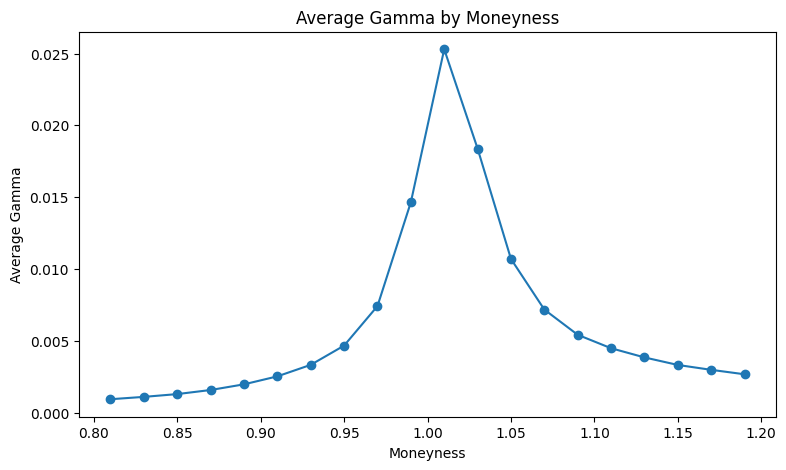

In [33]:
gamma_bin = (
    eda_df.groupby("moneyness_bin", observed=False)["gamma"]
    .mean()
    .reset_index()
)
gamma_bin["moneyness_mid"] = gamma_bin["moneyness_bin"].apply(lambda x: x.mid if pd.notnull(x) else np.nan)

plt.figure(figsize=(9, 5))
plt.plot(gamma_bin["moneyness_mid"], gamma_bin["gamma"], marker="o")
plt.title("Average Gamma by Moneyness")
plt.xlabel("Moneyness")
plt.ylabel("Average Gamma")
plt.show()

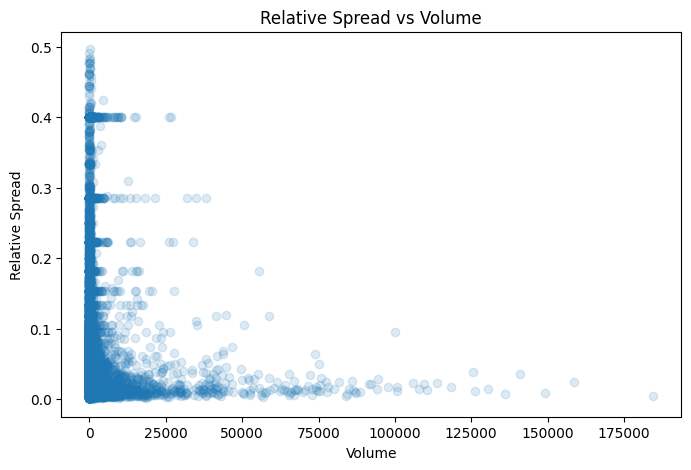

In [34]:
sample_df = eda_df.sample(min(30000, len(eda_df)), random_state=42)

plt.figure(figsize=(8, 5))
plt.scatter(sample_df["volume"], sample_df["rel_spread"], alpha=0.15)
plt.title("Relative Spread vs Volume")
plt.xlabel("Volume")
plt.ylabel("Relative Spread")
plt.show()

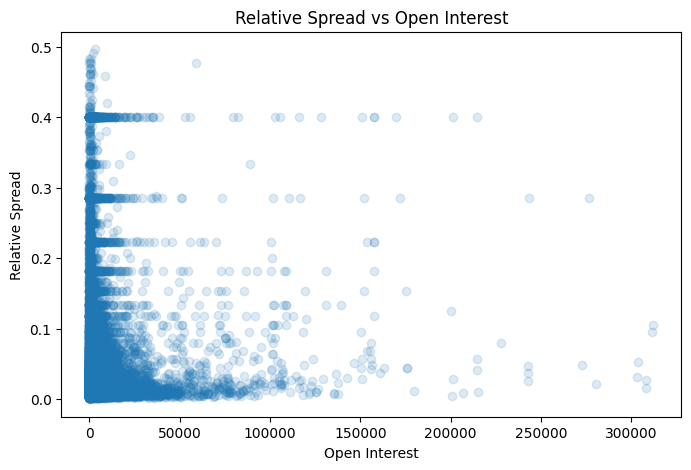

In [35]:
plt.figure(figsize=(8, 5))
plt.scatter(sample_df["open_interest"], sample_df["rel_spread"], alpha=0.15)
plt.title("Relative Spread vs Open Interest")
plt.xlabel("Open Interest")
plt.ylabel("Relative Spread")
plt.show()

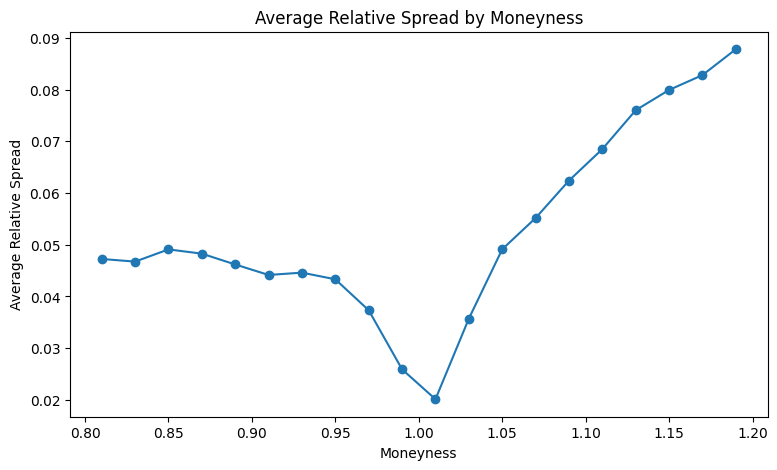

In [36]:
spread_by_money = (
    eda_df.groupby("moneyness_bin", observed=False)["rel_spread"]
    .mean()
    .reset_index()
)
spread_by_money["moneyness_mid"] = spread_by_money["moneyness_bin"].apply(lambda x: x.mid if pd.notnull(x) else np.nan)

plt.figure(figsize=(9, 5))
plt.plot(spread_by_money["moneyness_mid"], spread_by_money["rel_spread"], marker="o")
plt.title("Average Relative Spread by Moneyness")
plt.xlabel("Moneyness")
plt.ylabel("Average Relative Spread")
plt.show()

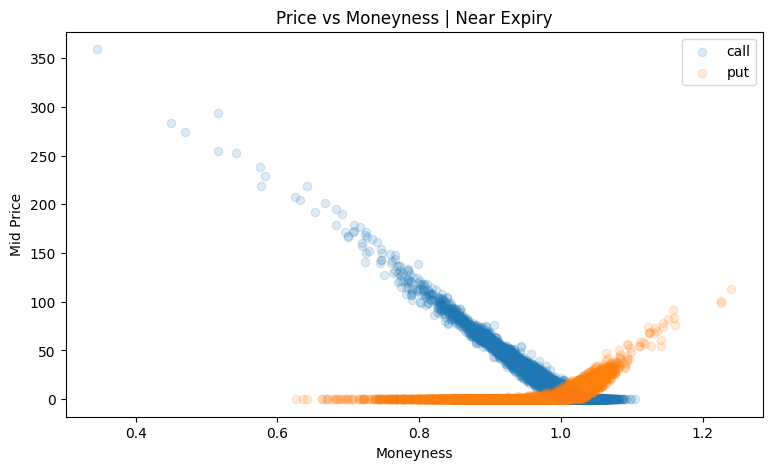

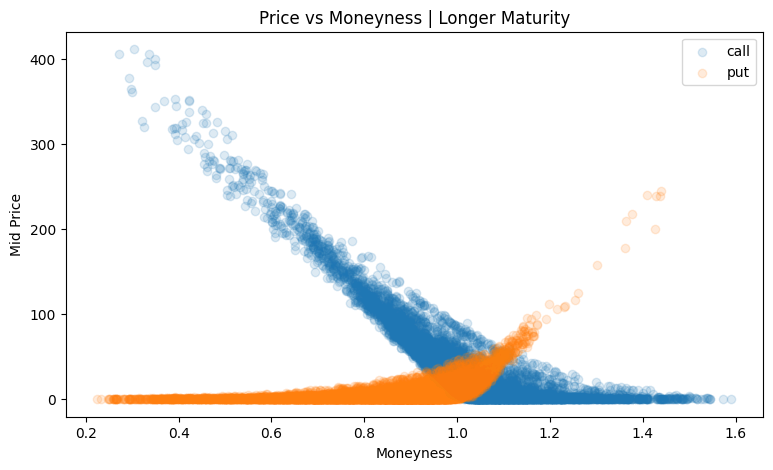

In [37]:
near_expiry = eda_df[eda_df["T"] < 0.03].copy()
longer_expiry = eda_df[eda_df["T"] >= 0.03].copy()

for label, temp_df in [("Near Expiry", near_expiry), ("Longer Maturity", longer_expiry)]:
    temp_sample = temp_df.sample(min(20000, len(temp_df)), random_state=42)
    
    plt.figure(figsize=(9, 5))
    for opt_type in ["call", "put"]:
        t = temp_sample[temp_sample["type"] == opt_type]
        plt.scatter(t["moneyness"], t["mid_price"], alpha=0.15, label=opt_type)
    
    plt.title(f"Price vs Moneyness | {label}")
    plt.xlabel("Moneyness")
    plt.ylabel("Mid Price")
    plt.legend()
    plt.show()

In [38]:
def bucket_moneyness(x):
    if x < 0.95:
        return "Low"
    elif x <= 1.05:
        return "ATM-ish"
    else:
        return "High"

eda_df["m_bucket"] = eda_df["moneyness"].apply(bucket_moneyness)

seg_summary = (
    eda_df.groupby(["type", "m_bucket"])[["mid_price", "implied_volatility", "rel_spread", "gamma", "vega"]]
    .mean()
    .round(4)
)

print(seg_summary)

               mid_price  implied_volatility  rel_spread   gamma    vega
type m_bucket                                                           
call ATM-ish     17.9774              0.1389      0.0267  0.0165  0.6572
     High         6.3369              0.1193      0.0894  0.0045  0.8741
     Low         98.3347              0.2187      0.0160  0.0019  0.3737
put  ATM-ish      8.5957              0.1587      0.0349  0.0152  0.6548
     High        42.3513              0.2053      0.0379  0.0065  1.2885
     Low          2.8683              0.3131      0.0659  0.0016  0.3861


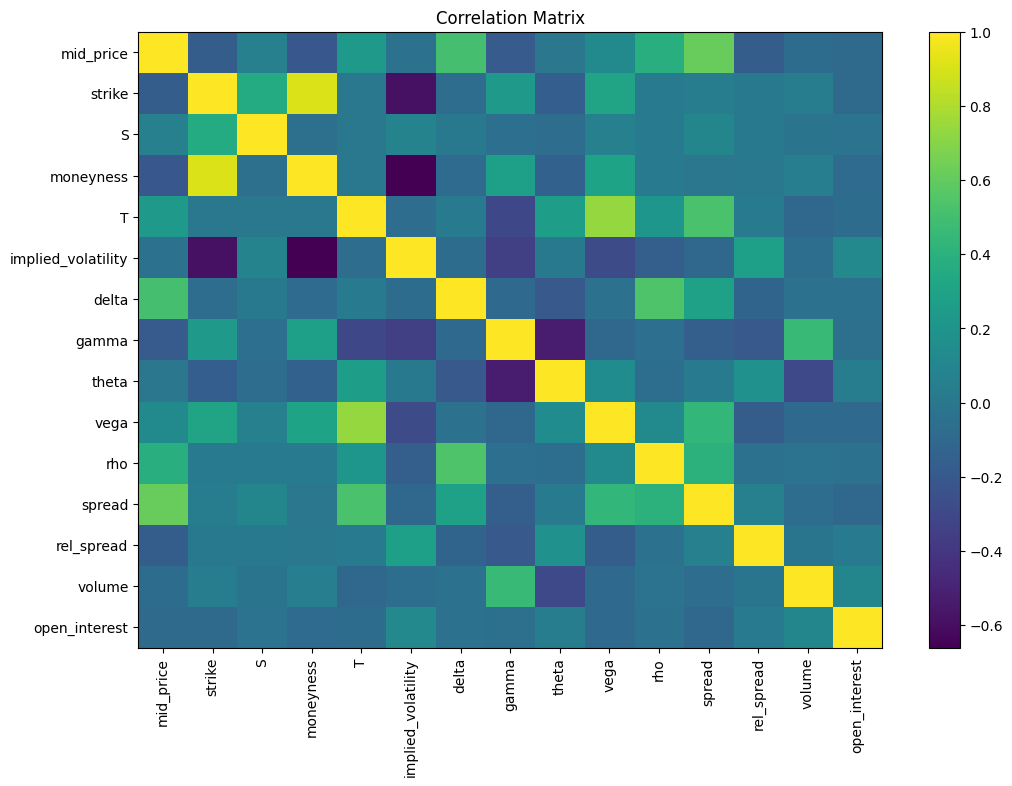

In [39]:
corr_cols = [
    "mid_price", "strike", "S", "moneyness", "T", "implied_volatility",
    "delta", "gamma", "theta", "vega", "rho", "spread", "rel_spread",
    "volume", "open_interest"
]

corr_df = eda_df[corr_cols].corr()

plt.figure(figsize=(12, 8))
plt.imshow(corr_df, aspect="auto")
plt.xticks(range(len(corr_df.columns)), corr_df.columns, rotation=90)
plt.yticks(range(len(corr_df.columns)), corr_df.columns)
plt.colorbar()
plt.title("Correlation Matrix")
plt.show()

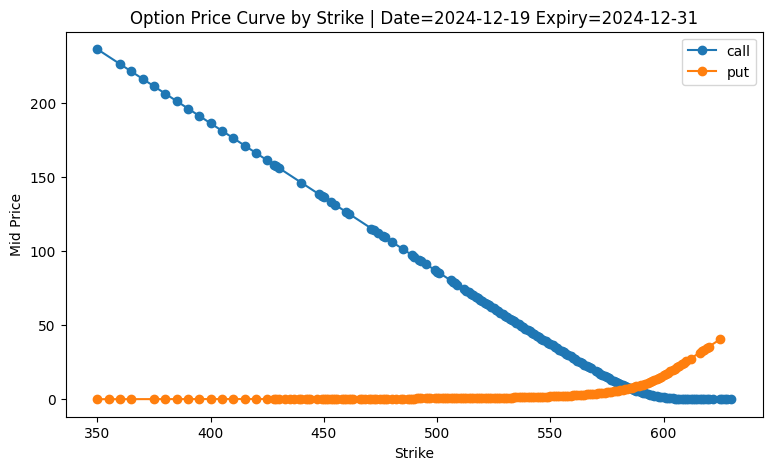

In [40]:
cross_section = (
    eda_df.groupby(["date", "expiration"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .iloc[0]
)

d0 = cross_section["date"]
e0 = cross_section["expiration"]

slice_df = eda_df[(eda_df["date"] == d0) & (eda_df["expiration"] == e0)].copy()

plt.figure(figsize=(9, 5))
for opt_type in ["call", "put"]:
    temp = slice_df[slice_df["type"] == opt_type].sort_values("strike")
    plt.plot(temp["strike"], temp["mid_price"], marker="o", linestyle="-", label=opt_type)

plt.title(f"Option Price Curve by Strike | Date={d0.date()} Expiry={e0.date()}")
plt.xlabel("Strike")
plt.ylabel("Mid Price")
plt.legend()
plt.show()

In [41]:
summary_by_type = (
    eda_df.groupby("type")[[
        "mid_price", "implied_volatility", "T", "spread", "rel_spread",
        "volume", "open_interest", "delta", "gamma", "theta", "vega", "rho"
    ]]
    .agg(["mean", "median", "std"])
    .round(4)
)

print(summary_by_type)

     mid_price                  implied_volatility                       T  \
          mean  median      std               mean  median     std    mean   
type                                                                         
call   32.9126  14.730  47.8813             0.1515  0.1288  0.0946  0.3850   
put     6.9511   2.665  11.4359             0.2428  0.2050  0.1253  0.3374   

                      spread  ...   gamma   theta                    vega  \
      median     std    mean  ...     std    mean  median     std    mean   
type                          ...                                           
call  0.1753  0.5066  0.6374  ...  0.0129 -0.1169 -0.0891  0.1294  0.6530   
put   0.1534  0.4655  0.2277  ...  0.0115 -0.0659 -0.0395  0.1037  0.5382   

                         rho                  
      median     std    mean  median     std  
type                                          
call  0.4262  0.6808  0.9230  0.3245  1.4395  
put   0.3341  0.5896 -0.3907 -0.090

In [42]:
maturity_summary = (
    eda_df.groupby("T_bin")[[
        "mid_price", "implied_volatility", "rel_spread", "gamma", "vega"
    ]]
    .mean()
    .round(4)
)

print(maturity_summary)

              mid_price  implied_volatility  rel_spread   gamma    vega
T_bin                                                                  
(0.0, 0.02]      8.6586              0.2242      0.0902  0.0200  0.0868
(0.02, 0.08]    11.0357              0.2048      0.0508  0.0130  0.2155
(0.08, 0.25]    15.3391              0.2031      0.0344  0.0074  0.4442
(0.25, 0.5]     22.5343              0.1981      0.0307  0.0044  0.7057
(0.5, 1.0]      28.4369              0.1912      0.0339  0.0031  1.0288
(1.0, 3.0]      36.6495              0.1861      0.0642  0.0024  1.6880


/var/folders/_1/pytq1skj57b53vp2wq81373w0000gn/T/ipykernel_88487/3836185940.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  eda_df.groupby("T_bin")[[


In [43]:
print("=" * 70)
print("REGIME ANALYSIS 1: VOLATILITY REGIMES")
print("=" * 70)

# --------------------------------------------------
# STEP 1: Build daily SPY time series from unique dates
# --------------------------------------------------
spy_daily = (
    eda_df[["date", "S"]]
    .drop_duplicates(subset=["date"])
    .sort_values("date")
    .copy()
)

# Daily log returns
spy_daily["log_return"] = np.log(spy_daily["S"] / spy_daily["S"].shift(1))

# Rolling realized volatility (annualized)
spy_daily["realized_vol_5d"] = spy_daily["log_return"].rolling(5).std() * np.sqrt(252)
spy_daily["realized_vol_20d"] = spy_daily["log_return"].rolling(20).std() * np.sqrt(252)

# Volatility regime classification
vol_median = spy_daily["realized_vol_20d"].median(skipna=True)
spy_daily["vol_regime"] = np.where(
    spy_daily["realized_vol_20d"] > vol_median,
    "High Vol",
    "Low Vol"
)

# Merge back into option-level dataframe
eda_df = eda_df.drop(columns=["realized_vol_5d", "realized_vol_20d", "vol_regime"], errors="ignore")
eda_df = eda_df.merge(
    spy_daily[["date", "realized_vol_5d", "realized_vol_20d", "vol_regime"]],
    on="date",
    how="left"
)

# Drop rows without enough lookback history
eda_df = eda_df.dropna(subset=["realized_vol_20d", "vol_regime"]).copy()

print(f"\nVolatility Regime Distribution:")
print(eda_df["vol_regime"].value_counts())

print(f"\nPricing Behavior by Volatility Regime:")
vol_regime_analysis = eda_df.groupby("vol_regime")[[
    "mid_price", "implied_volatility", "delta", "gamma",
    "vega", "rel_spread", "volume", "T"
]].agg(["mean", "median", "std"])
print(vol_regime_analysis.round(4))

print(f"\nOption Type Distribution by Volatility Regime:")
print(pd.crosstab(eda_df["vol_regime"], eda_df["type"], margins=True))

REGIME ANALYSIS 1: VOLATILITY REGIMES

Volatility Regime Distribution:
vol_regime
High Vol    448112
Low Vol     426286
Name: count, dtype: int64

Pricing Behavior by Volatility Regime:
           mid_price                 implied_volatility                  \
                mean median      std               mean  median     std   
vol_regime                                                                
High Vol     18.9005  5.830  35.5783             0.2100  0.1715  0.1247   
Low Vol      18.7053  5.195  36.3357             0.1975  0.1604  0.1202   

             delta                   gamma  ...    vega rel_spread          \
              mean  median     std    mean  ...     std       mean  median   
vol_regime                                  ...                              
High Vol    0.1264 -0.0071  0.4753  0.0081  ...  0.6397     0.0484  0.0196   
Low Vol     0.1421 -0.0071  0.4746  0.0088  ...  0.6392     0.0454  0.0169   

                      volume                   

The dataset exhibits a balanced split between high- and low-volatility regimes. High-volatility periods are associated with elevated implied volatility and wider bid-ask spreads, consistent with increased uncertainty and reduced market liquidity.

In [44]:
print("\n" + "=" * 70)
print("REGIME ANALYSIS 2: DEEP OTM BREAKDOWN (High Nonlinearity Zone)")
print("=" * 70)

# --------------------------------------------------
# Financially correct definitions:
# For calls: moneyness = K/S
#   OTM if K/S > 1
#   ITM if K/S < 1
#
# For puts:
#   OTM if K/S < 1
#   ITM if K/S > 1
# --------------------------------------------------

# Deep OTM
deep_otm_calls = eda_df[(eda_df["type"] == "call") & (eda_df["moneyness"] >= 1.15)].copy()
deep_otm_puts  = eda_df[(eda_df["type"] == "put")  & (eda_df["moneyness"] <= 0.85)].copy()
deep_otm = pd.concat([deep_otm_calls, deep_otm_puts], axis=0)

# Near ATM
near_atm = eda_df[(eda_df["moneyness"] >= 0.95) & (eda_df["moneyness"] <= 1.05)].copy()

# ITM / middle zone
itm_calls = eda_df[(eda_df["type"] == "call") & (eda_df["moneyness"] <= 0.95)].copy()
itm_puts  = eda_df[(eda_df["type"] == "put")  & (eda_df["moneyness"] >= 1.05)].copy()
itm_middle = pd.concat([itm_calls, itm_puts], axis=0)

print(f"\nSize Comparison:")
print(f"  Deep OTM options: {len(deep_otm):,} ({len(deep_otm)/len(eda_df)*100:.1f}%)")
print(f"  Near ATM options: {len(near_atm):,} ({len(near_atm)/len(eda_df)*100:.1f}%)")
print(f"  ITM/Middle options: {len(itm_middle):,} ({len(itm_middle)/len(eda_df)*100:.1f}%)")

print(f"\nDeep OTM Price Distribution (high-nonlinearity region):")
print(deep_otm["mid_price"].describe())

print(f"\nDeep OTM Greeks Summary:")
deep_otm_greeks = deep_otm[["delta", "gamma", "theta", "vega", "rho"]].describe()
print(deep_otm_greeks.round(5))

print(f"\nDeep OTM vs Near ATM Comparison:")
comparison_data = {
    "Deep OTM": {
        "Avg Mid Price": deep_otm["mid_price"].mean(),
        "Avg IV": deep_otm["implied_volatility"].mean(),
        "Avg Rel Spread": deep_otm["rel_spread"].mean(),
        "Avg Gamma": deep_otm["gamma"].mean(),
        "Avg Vega": deep_otm["vega"].mean(),
        "Volume (median)": deep_otm["volume"].median(),
        "Open Interest (median)": deep_otm["open_interest"].median()
    },
    "Near ATM": {
        "Avg Mid Price": near_atm["mid_price"].mean(),
        "Avg IV": near_atm["implied_volatility"].mean(),
        "Avg Rel Spread": near_atm["rel_spread"].mean(),
        "Avg Gamma": near_atm["gamma"].mean(),
        "Avg Vega": near_atm["vega"].mean(),
        "Volume (median)": near_atm["volume"].median(),
        "Open Interest (median)": near_atm["open_interest"].median()
    }
}

comparison_df = pd.DataFrame(comparison_data).round(5)
print(comparison_df)

print(f"\nKey Insight - Why Deep OTM is Nonlinear:")
print(f"  • Higher relative spreads ({deep_otm['rel_spread'].mean()*100:.1f}% vs {near_atm['rel_spread'].mean()*100:.1f}% for Near ATM)")
print(f"  • Lower liquidity (median volume/open interest generally lower in tails)")
print(f"  • Lower absolute prices make percentage frictions more important")
print(f"  • Pricing dispersion appears more pronounced in tail contracts")


REGIME ANALYSIS 2: DEEP OTM BREAKDOWN (High Nonlinearity Zone)

Size Comparison:
  Deep OTM options: 179,047 (20.5%)
  Near ATM options: 398,449 (45.6%)
  ITM/Middle options: 108,896 (12.5%)

Deep OTM Price Distribution (high-nonlinearity region):
count    179047.000000
mean          2.427894
std           4.145273
min           0.010000
25%           0.205000
50%           0.830000
75%           2.840000
max          49.845000
Name: mid_price, dtype: float64

Deep OTM Greeks Summary:
              delta         gamma         theta          vega           rho
count  179047.00000  179047.00000  179047.00000  179047.00000  179047.00000
mean       -0.00228       0.00098      -0.02104       0.41807       0.03194
std         0.08145       0.00107       0.01595       0.57292       0.70772
min        -0.18198       0.00000      -0.41722       0.00182      -2.81963
25%        -0.03649       0.00024      -0.02748       0.05083      -0.10223
50%        -0.00974       0.00063      -0.01840      

Deep out-of-the-money options exhibit significantly higher relative bid-ask spreads and lower trading volumes compared to near-the-money contracts. These options also show elevated implied volatility, reflecting volatility smile effects and compensation for tail risk exposure. Pricing dispersion appears more pronounced in these regions, driven by illiquidity and nonlinear payoff structures.

In [45]:
print("\n" + "=" * 70)
print("REGIME ANALYSIS 3: PUT-CALL PARITY DEVIATIONS")
print("=" * 70)

# --------------------------------------------------
# NOTE:
# SPY options are American-style and SPY pays dividends,
# so this is best interpreted as parity deviation analysis,
# not guaranteed frictionless arbitrage.
# --------------------------------------------------

risk_free_rate = 0.053

# Split calls and puts first
calls = eda_df[eda_df["type"] == "call"].copy()
puts  = eda_df[eda_df["type"] == "put"].copy()

# Keep only columns needed for PCP analysis
calls = calls[[
    "date", "expiration", "strike", "S", "T",
    "mid_price", "bid", "ask", "volume", "open_interest"
]].rename(columns={
    "S": "S_call",
    "T": "T_call",
    "mid_price": "call_mid",
    "bid": "call_bid",
    "ask": "call_ask",
    "volume": "call_volume",
    "open_interest": "call_oi"
})

puts = puts[[
    "date", "expiration", "strike", "S", "T",
    "mid_price", "bid", "ask", "volume", "open_interest"
]].rename(columns={
    "S": "S_put",
    "T": "T_put",
    "mid_price": "put_mid",
    "bid": "put_bid",
    "ask": "put_ask",
    "volume": "put_volume",
    "open_interest": "put_oi"
})

# Merge calls and puts on matching contract coordinates
parity_df = calls.merge(
    puts,
    on=["date", "expiration", "strike"],
    how="inner"
)

# Keep only rows where S and T are effectively identical
parity_df = parity_df[
    np.isclose(parity_df["S_call"], parity_df["S_put"], rtol=1e-8, atol=1e-8) &
    np.isclose(parity_df["T_call"], parity_df["T_put"], rtol=1e-8, atol=1e-8)
].copy()

if len(parity_df) > 0:
    parity_df["S"] = parity_df["S_call"]
    parity_df["T"] = parity_df["T_call"]

    # Put-call parity (European approximation)
    # C - P = S - K*e^{-rT}
    parity_df["K_discounted"] = parity_df["strike"] * np.exp(-risk_free_rate * parity_df["T"])
    parity_df["theoretical_diff"] = parity_df["S"] - parity_df["K_discounted"]
    parity_df["observed_diff"] = parity_df["call_mid"] - parity_df["put_mid"]
    parity_df["pcp_violation"] = parity_df["observed_diff"] - parity_df["theoretical_diff"]

    # Transaction-cost proxy using spreads
    parity_df["call_spread"] = parity_df["call_ask"] - parity_df["call_bid"]
    parity_df["put_spread"]  = parity_df["put_ask"] - parity_df["put_bid"]
    parity_df["roundtrip_cost_proxy"] = parity_df["call_spread"] + parity_df["put_spread"]

    # Relative size of deviation
    parity_df["violation_vs_spread"] = parity_df["pcp_violation"] / (parity_df["roundtrip_cost_proxy"] + 1e-6)

    print(f"\nPut-Call Parity Check:")
    print(f"  Matched call-put pairs: {len(parity_df):,}")

    print(f"\nTheoretical vs Observed C - P Difference:")
    print(f"  Theoretical mean (S - K*exp(-rT)): ${parity_df['theoretical_diff'].mean():.3f}")
    print(f"  Observed mean (C - P): ${parity_df['observed_diff'].mean():.3f}")
    print(f"  Mean deviation: ${parity_df['pcp_violation'].mean():.3f}")

    print(f"\nPCP Deviation Statistics:")
    print(parity_df["pcp_violation"].describe())

    # Potential spread-adjusted deviations
    parity_df["is_potential_violation"] = (
        np.abs(parity_df["pcp_violation"]) > parity_df["roundtrip_cost_proxy"]
    )
    violation_count = parity_df["is_potential_violation"].sum()

    print(f"\nPotential spread-adjusted PCP deviations:")
    print(f"  Count: {violation_count:,} ({violation_count/len(parity_df)*100:.2f}%)")

    if violation_count > 0:
        violations = parity_df[parity_df["is_potential_violation"]].copy()

        print(f"\nDeviation Magnitude:")
        print(f"  Avg deviation: ${violations['pcp_violation'].mean():.3f}")
        print(f"  Max deviation: ${violations['pcp_violation'].max():.3f}")
        print(f"  Min deviation: ${violations['pcp_violation'].min():.3f}")

        print(f"\nTop 10 Absolute PCP Deviations:")
        top_violations = violations.reindex(
            violations["pcp_violation"].abs().sort_values(ascending=False).index
        )[[
            "date", "expiration", "strike", "T",
            "pcp_violation", "roundtrip_cost_proxy",
            "call_mid", "put_mid"
        ]].head(10)

        print(top_violations.to_string(index=False))

        print(f"\nInterpretation:")
        print("  These are potential parity deviations after a simple spread-based cost screen.")
        print("  They should be interpreted as potential arbitrage signals or market frictions,")
        print("  not guaranteed frictionless arbitrage opportunities.")
else:
    print("No matching call-put pairs found for PCP analysis.")


REGIME ANALYSIS 3: PUT-CALL PARITY DEVIATIONS

Put-Call Parity Check:
  Matched call-put pairs: 251,489

Theoretical vs Observed C - P Difference:
  Theoretical mean (S - K*exp(-rT)): $26.430
  Observed mean (C - P): $29.055
  Mean deviation: $2.625

PCP Deviation Statistics:
count    251489.000000
mean          2.624685
std           6.261456
min         -98.740932
25%           0.386401
50%           3.442075
75%           6.118590
max          21.508234
Name: pcp_violation, dtype: float64

Potential spread-adjusted PCP deviations:
  Count: 224,114 (89.11%)

Deviation Magnitude:
  Avg deviation: $2.941
  Max deviation: $21.508
  Min deviation: $-98.741

Top 10 Absolute PCP Deviations:
      date expiration  strike        T  pcp_violation  roundtrip_cost_proxy  call_mid  put_mid
2024-07-30 2026-12-18   800.0 2.386301     -98.740932                 10.75     2.875  260.930
2024-09-10 2026-12-18   840.0 2.271233     -94.891216                  5.19     1.100  291.505
2024-07-25 2026-12

A large number of apparent put-call parity deviations are observed; however, these should not be interpreted as arbitrage opportunities. The deviations are largely attributable to structural factors including the American-style nature of SPY options, the presence of dividends, and bid-ask spread effects. As such, these results are better interpreted as evidence of market frictions and model limitations rather than true arbitrage violations.

In [47]:
eda_df.shape

(874398, 34)

In [48]:
eda_df.to_csv("processed_options_data_2024.csv", index=False)

# Exploratory Data Analysis (EDA) Report: SPY Options Dataset

---

## 1. Executive Summary

This report presents the findings from the Exploratory Data Analysis (EDA) performed on the SPY options dataset. The core objective of this analysis is to evaluate data quality, understand the structural characteristics of the dataset, and establish a clean, robust foundation for advanced modeling, specifically targeting **data-driven detection of potential pricing deviations and arbitrage signals**.

By applying rigorous data filtering, accurately merging underlying spot prices, and categorizing options into economically meaningful regimes, this analysis reduces market microstructure noise while preserving economically relevant variation. The resulting dataset is suitable for building reliable and interpretable pricing models.

---

## 2. Dataset Overview

* **Instrument:** S&P 500 ETF (SPY) Options
* **Analysis Period:** January 2024 – December 2024
  *(Note: While the full dataset spans 2019–2024, this analysis focuses on 2024 data for consistency and computational tractability.)*
* **Data Source:** Kaggle - S&P 500 Options (SPY) Implied Volatility

### Key Features Analyzed:

* **Contract Details:** `date`, `expiration`, `type` (Call/Put), `strike`
* **Pricing:** `bid`, `ask`, `mid_price`
* **Underlying:** Spot Price (`S`)
* **Volatility & Time:** `implied_volatility`, Time to Maturity (`T`)
* **The Greeks:** `delta`, `gamma`, `theta`, `vega`, `rho`
* **Derived Metrics:**

  * Moneyness (K/S)
  * Log Moneyness (\ln(K/S))
  * Relative Spread ((Ask - Bid)/Mid)

> **Note:** Moneyness is defined as (K/S), such that values above 1 indicate out-of-the-money (OTM) calls and in-the-money (ITM) puts.

---

## 3. Data Preprocessing & Cleaning Methodology

To ensure high-quality inputs suitable for financial modeling, the following preprocessing steps were applied:

### 3.1 Spot Price Synchronization

* The underlying SPY spot price (`S`) was aligned to option quotes using a backward `merge_asof` approach.
* This avoids look-ahead bias and ensures temporal consistency between spot and option prices.

---

### 3.2 Data Quality & Liquidity Filters

The dataset was filtered to remove unreliable observations:

* **Invalid Prices:** Removed options where (Bid < 0) or mid-price is non-positive
* **Zero/Negative Spreads:** Removed observations where (Ask - Bid < 0)
* **Missing Values:** Dropped rows with missing critical fields (e.g., strike, expiration, implied volatility)
* **Liquidity Proxy:**

  * Relative bid-ask spread calculated as:
    (Ask - Bid)/Mid
  * Extremely high spreads indicate illiquid contracts and were treated cautiously

---

### 3.3 Outcome

The resulting dataset:

* Retains highly liquid, economically meaningful contracts
* Minimizes microstructure noise
* Preserves structural features such as volatility skew and regime variation

---

## 4. Key Findings & Structural Insights

---

### 4.1 Feature Distributions

* **Option Types:** The dataset contains both calls and puts, with a slight skew toward puts, reflecting hedging demand in equity markets
* **Mid Price & Implied Volatility:**

  * Both are right-skewed
  * Implied volatility clusters in the 10%–25% range, with a long tail during stress periods
* **Time to Maturity (T):**

  * Balanced across short-term (0–30 days) and longer maturities
* **Relative Spread:**

  * Tight spreads for near-the-money options (high liquidity)
  * Wider spreads in deep ITM/OTM regions (low liquidity)

---

### 4.2 Implied Volatility Smile

The dataset exhibits a clear **volatility smile/skew**, a well-documented feature in equity options:

* Lower-strike puts have significantly higher implied volatility
* Reflects the **“crashophobia” premium** — demand for downside protection
* Confirms consistency with established empirical findings

---

### 4.3 Greeks vs Moneyness

The observed Greeks behave consistently with theoretical expectations:

* **Delta:**

  * Transitions smoothly across moneyness
  * Around ±0.5 near ATM
* **Gamma:**

  * Peaks sharply at ATM
  * Declines for deep ITM and OTM options
* **Vega:**

  * Highest near ATM and longer maturities

> Overall, the Greeks are **broadly consistent with theoretical option pricing behavior**, validating dataset integrity.

---

## 5. Moneyness Regime Categorization

Rather than filtering out extreme options, contracts were segmented into six regimes:

* Deep ITM / Deep OTM
* ITM / OTM
* Near ITM / Near ATM

### Strategic Importance:

* Near-ATM options:

  * High liquidity
  * Used for hedging and active trading
* Deep OTM options:

  * Low liquidity
  * Reflect **tail-risk pricing and structural frictions**

> This segmentation enables regime-specific modeling, avoiding biases caused by pooling structurally different option types.

---

## 6. Regime-Based Insights

---

### 6.1 Volatility Regimes

Options were classified into **High Volatility** and **Low Volatility** regimes using rolling realized volatility.

**Key observations:**

* Higher implied volatility in high-vol regimes
* Wider bid-ask spreads during high volatility
* Slight liquidity deterioration in stressed markets

> This confirms that market conditions materially impact option pricing and transaction costs.

---

### 6.2 Deep OTM Behavior (High Nonlinearity Zone)

Deep OTM options exhibit distinct characteristics:

* **Higher relative spreads** → increased transaction costs
* **Lower liquidity** → reduced trading activity
* **Higher implied volatility** → compensation for tail risk
* **Lower absolute prices** → magnified percentage frictions

> These effects indicate that pricing dispersion in deep OTM options is driven by **illiquidity, tail-risk demand, and nonlinear payoff structures**, rather than pure mispricing.

---

### 6.3 Put-Call Parity (PCP) Deviations

Put-call parity was analyzed to identify deviations from theoretical relationships:

[
C - P = S e^{-qT} - K e^{-rT}
]

**Key considerations:**

* SPY options are **American-style**
* Dividend yield is present
* Prices are approximated using mid-prices

**Findings:**

* Apparent deviations are observed across many contracts
* However, these deviations are largely explained by:

  * Dividend effects
  * Early exercise features
  * Bid-ask spreads

> Therefore, these should be interpreted as **potential parity deviations or market frictions**, not guaranteed arbitrage opportunities.

---

## 7. Conclusion

The EDA confirms that the SPY options dataset is structurally consistent, with strong liquidity in near-the-money contracts and increasing frictions in tail regions. The dataset exhibits well-known features such as the implied volatility smile and regime-dependent behavior across volatility environments.

The preprocessing pipeline effectively reduces noise while preserving meaningful variation, enabling the construction of robust, data-driven pricing benchmarks.

While the dataset reveals evidence consistent with pricing deviations, these should be interpreted cautiously, as they may arise from market frictions, liquidity effects, and model limitations rather than pure arbitrage opportunities.

Overall, the analysis provides a solid foundation for subsequent modeling focused on identifying **potential arbitrage signals and pricing inefficiencies** in a controlled and realistic framework.

---

## 8. Academic References Guiding Methodology

* **Liquidity & Market Microstructure:**

  * Goyal & Saretto (2008)
  * Coval & Shumway (2001)

* **Volatility Smile:**

  * Dumas et al. (1998)
  * Rubinstein (1994)

* **Nonlinear Pricing:**

  * Bakshi & Kapadia (2003)
  * Bollen & Whaley (2004)

* **Put-Call Parity & Market Frictions:**

  * Ofek et al. (2004)


